In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cell 2: Load Cleaned Data
df = pd.read_csv("../data/sales_data_cleaned.csv")
df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
print(df.columns.tolist())
df.head()

(76000, 26)
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand', 'Year', 'Month', 'Week', 'Day', 'Quarter', 'Net_Price', 'Discount_Flag', 'Stock_Gap', 'Stockout_Risk', 'Demand_to_Inventory_Ratio']


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Year,Month,Week,Day,Quarter,Net_Price,Discount_Flag,Stock_Gap,Stockout_Risk,Demand_to_Inventory_Ratio
0,2022-01-01,S001,P0001,Electronics,North,195.0,102.0,252,72.72,5,...,2022,1,52,1,1,69.084,1,93.0,0,0.586735
1,2022-01-01,S001,P0002,Clothing,North,117.0,117.0,249,80.16,15,...,2022,1,52,1,1,68.136,1,0.0,0,1.915254
2,2022-01-01,S001,P0003,Clothing,North,247.0,114.0,612,62.94,10,...,2022,1,52,1,1,56.646,1,133.0,0,0.633065
3,2022-01-01,S001,P0004,Electronics,North,139.0,45.0,102,87.63,10,...,2022,1,52,1,1,78.867,1,94.0,0,0.371429
4,2022-01-01,S001,P0005,Groceries,North,152.0,65.0,271,54.41,0,...,2022,1,52,1,1,54.410,0,87.0,0,0.385621


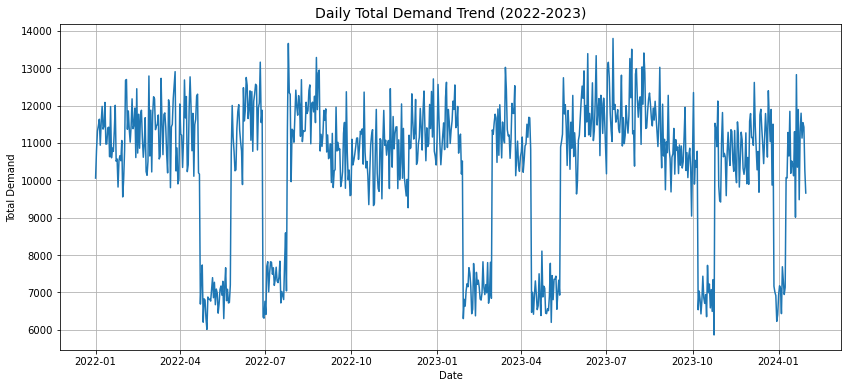

In [3]:
# Cell 3: Overall Sales Trend
plt.figure(figsize=(14, 6))
daily_sales = df.groupby('Date')['Demand'].sum().reset_index()
plt.plot(daily_sales['Date'], daily_sales['Demand'])
plt.title('Daily Total Demand Trend (2022-2023)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.grid(True)
plt.show()

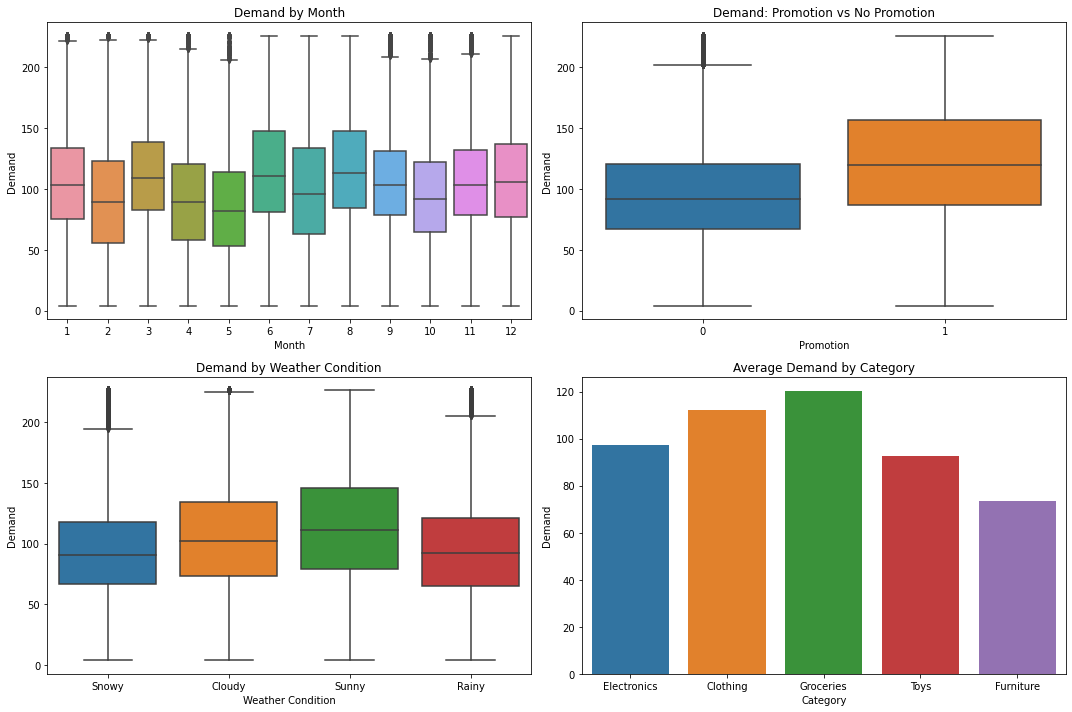

In [4]:
# Cell 4: Seasonality & Consumer Behavior Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Monthly Seasonality
sns.boxplot(x='Month', y='Demand', data=df, ax=axes[0,0])
axes[0,0].set_title('Demand by Month')

# Promotion Impact (Key Consumer Behavior)
sns.boxplot(x='Promotion', y='Demand', data=df, ax=axes[0,1])
axes[0,1].set_title('Demand: Promotion vs No Promotion')

# Weather Impact
sns.boxplot(x='Weather Condition', y='Demand', data=df, ax=axes[1,0])
axes[1,0].set_title('Demand by Weather Condition')

# Category Performance
sns.barplot(x='Category', y='Demand', data=df, ax=axes[1,1], ci=None)
axes[1,1].set_title('Average Demand by Category')

plt.tight_layout()
plt.show()

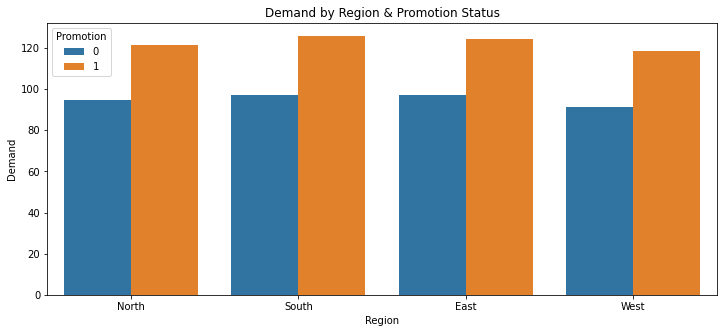

In [5]:
# Cell 5: Regional & Store Analysis
plt.figure(figsize=(12, 5))
sns.barplot(x='Region', y='Demand', hue='Promotion', data=df, ci=None)
plt.title('Demand by Region & Promotion Status')
plt.show()

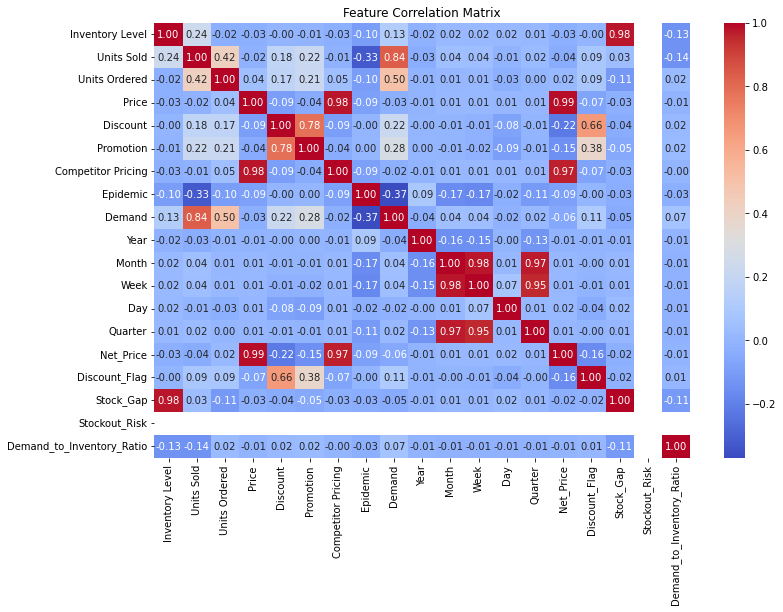

In [6]:
# Cell 6: Correlation Heatmap (Important for Modeling)
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

In [7]:
# Cell 7: Key Insights Summary
print("=== KEY CONSUMER BEHAVIOR INSIGHTS ===\n")
print(f"1. Total Records          : {len(df):,}")
print(f"2. Promotion Lift         : {df[df['Promotion']==1]['Demand'].mean() / df[df['Promotion']==0]['Demand'].mean():.2f}x")
print(f"3. Average Demand         : {df['Demand'].mean():.1f}")
print(f"4. Highest Demand Category: {df.groupby('Category')['Demand'].mean().idxmax()}")
print(f"5. Epidemic Impact        : {df[df['Epidemic']==1]['Demand'].mean():.1f} vs Normal {df[df['Epidemic']==0]['Demand'].mean():.1f}")

=== KEY CONSUMER BEHAVIOR INSIGHTS ===

1. Total Records          : 76,000
2. Promotion Lift         : 1.29x
3. Average Demand         : 104.0
4. Highest Demand Category: Groceries
5. Epidemic Impact        : 70.1 vs Normal 112.4
